In [1]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

# Initial work

## Data loading

In [2]:
# read mESC transcript counts
data_d0 = pd.read_csv("./Data/GSE151334_d0_counts_common.csv", index_col=0)
data_d4 = pd.read_csv("./Data/GSE151334_d4_counts_common.csv", index_col=0)
data_d8 = pd.read_csv("./Data/GSE151334_d8_counts_common.csv", index_col=0)
data_d12 = pd.read_csv("./Data/GSE151334_d12_counts_common.csv", index_col=0)

# load capture
beta_d0 = np.loadtxt("./Capture/beta_d0.txt")
beta_d4 = np.loadtxt("./Capture/beta_d4.txt")
beta_d8 = np.loadtxt("./Capture/beta_d8.txt")
beta_d12 = np.loadtxt("./Capture/beta_d12.txt")

# load RNA types
biotypes_dict = json.load(open("./Biotypes/biotypes_common.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# select protein coding genes
data_d0_pcRNA = data_d0.iloc[pcRNA_indices]
data_d4_pcRNA = data_d4.iloc[pcRNA_indices]
data_d8_pcRNA = data_d8.iloc[pcRNA_indices]
data_d12_pcRNA = data_d12.iloc[pcRNA_indices]

# select micro RNA genes
data_d0_miRNA = data_d0.iloc[miRNA_indices]
data_d4_miRNA = data_d4.iloc[miRNA_indices]
data_d8_miRNA = data_d8.iloc[miRNA_indices]
data_d12_miRNA = data_d12.iloc[miRNA_indices]

# amounts: see './Biotypes/biotypes.ipynb' for full pie chart of types
print(f"Total of {data_d0.shape[0]} genes with mean > 1 present \nSelected {data_d0_miRNA.shape[0]} non-coding miRNA \nSelected {data_d0_pcRNA.shape[0]} protein coding (mRNA)")

Total of 7558 genes with mean > 1 present 
Selected 8 non-coding miRNA 
Selected 6431 protein coding (mRNA)


## Setup functions

In [3]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples=1000):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample
        gene_j = mrna_dataset.iloc[i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

In [4]:
def model_free_independence_test(dataset, d_bd, d_sd, **kwargs):

    # Independent model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=True
    )
    opt_MF_ind = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_ind.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_ind.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_ind.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_ind.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'model': opt_MF_ind
    }

    return data

In [5]:
def model_free_interacting_test(dataset, d_bd, d_sd, **kwargs):

    # Interacting model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_int.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
    correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'correlation': correlation,
        'model': opt_MF_int
    }

    return data

## Setup results

In [23]:
# select mRNA
G = 100
mRNA = data_d0_pcRNA.index[:G]

In [24]:
# dataframe to store model free results
MF_independent_df = pd.DataFrame(
    index=mRNA
)
MF_interacting_df = pd.DataFrame(
    index=mRNA
)

## Running

In [28]:
data_d0_miRNA.index

Index(['Mir1983', 'Mir692-1', 'Mir3091', 'Mir6236', 'Mir5119', 'Mir703',
       'Mir5136', 'Mir5110'],
      dtype='object')

In [29]:
# order choice
d_bd = 3
d_sd = 3

# settings
time_limit = 30
total_time_limit = 30
cut_limit = 100

# select miRNA
miRNA = "Mir1983"

# get datasets
data_miRNA_list = [data_d0_miRNA, data_d4_miRNA, data_d8_miRNA, data_d12_miRNA]
data_pcRNA_list = [data_d0_pcRNA, data_d4_pcRNA, data_d8_pcRNA, data_d12_pcRNA]
beta_list = [beta_d0, beta_d4, beta_d8, beta_d12]

# for each day
for i, day in enumerate([0, 4, 8, 12]):

    # display day
    print(f"\nRunning day {day}")

    # construct dataset of miRNA paired with mRNA
    dataset_SDP = construct_dataset(data_miRNA_list[i].loc[miRNA], data_pcRNA_list[i].loc[mRNA], beta_list[i])

    # bootstrap
    print("Bootstrap:")
    dataset_SDP.confidence = 0.95
    dataset_SDP.bootstrap(d=d_bd, tqdm_disable=False)

    # independence test
    print("MF Independence test:")
    MF_ind = model_free_independence_test(dataset_SDP, d_bd, d_sd, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_ind['status'], return_counts=True))

    # interacting test
    print("MF Interacting test:")
    MF_int = model_free_interacting_test(dataset_SDP, d_bd, d_sd, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_int['status'], return_counts=True))

    # store results on dataframe

    # independence test
    MF_independent_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status'] = MF_ind['status']
    MF_independent_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_times'] = MF_ind['times']
    MF_independent_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_cuts'] = MF_ind['cuts']

    # interacting test
    MF_interacting_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_status'] = MF_int['status']
    MF_interacting_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_times'] = MF_int['times']
    MF_interacting_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_cuts'] = MF_int['cuts']
    MF_interacting_df[f'{miRNA}_day{day}_d{d_bd}{d_sd}_t{time_limit}_ct{cut_limit}_correlation'] = MF_int['correlation']

    # save dataframes as safety
    MF_independent_df.to_csv("Results/independent_MF.csv")  # Uncomment when running
    MF_interacting_df.to_csv("Results/interacting_MF.csv")


Running day 0
Bootstrap:


100%|██████████| 100/100 [00:03<00:00, 28.72it/s]


MF Independence test:


100%|██████████| 100/100 [00:03<00:00, 30.38it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([ 2, 98]))
MF Interacting test:


...

MF Independence test:


100%|██████████| 100/100 [00:03<00:00, 33.05it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([24, 76]))
MF Interacting test:


100%|██████████| 100/100 [00:03<00:00, 29.89it/s]

(array(['OPTIMAL'], dtype='<U7'), array([100]))


# Plotting

In [30]:
MF_independent_df

,Mir1983_day0_d33_t30_ct100_status,Mir1983_day0_d33_t30_ct100_times,Mir1983_day0_d33_t30_ct100_cuts,Mir1983_day4_d33_t30_ct100_status,Mir1983_day4_d33_t30_ct100_times,Mir1983_day4_d33_t30_ct100_cuts,Mir1983_day8_d33_t30_ct100_status,Mir1983_day8_d33_t30_ct100_times,Mir1983_day8_d33_t30_ct100_cuts,Mir1983_day12_d33_t30_ct100_status,Mir1983_day12_d33_t30_ct100_times,Mir1983_day12_d33_t30_ct100_cuts
Napa,OPTIMAL,0.004,0,OPTIMAL,0.003,0,OPTIMAL,0.008,3,OPTIMAL,0.000,0
Rsl1d1,OPTIMAL,0.003,0,OPTIMAL,0.003,1,OPTIMAL,0.002,1,OPTIMAL,0.002,0
Usp3,OPTIMAL,0.001,0,OPTIMAL,0.001,0,INFEASIBLE,0.000,0,OPTIMAL,0.001,0
Odf2l,OPTIMAL,0.001,0,OPTIMAL,0.001,4,INFEASIBLE,0.000,0,OPTIMAL,0.002,0
Cdk1,OPTIMAL,0.004,1,OPTIMAL,0.002,1,OPTIMAL,0.002,1,OPTIMAL,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...
Mrpl13,OPTIMAL,0.002,1,OPTIMAL,0.005,3,OPTIMAL,0.001,1,OPTIMAL,0.002,0
Ubfd1,OPTIMAL,0.004,1,OPTIMAL,0.001,0,OPTIMAL,0.002,0,OPTIMAL,0.002,0
Stk24,OPTIMAL,0.003,2,OPTIMAL,0.001,0,OPTIMAL,0.004,3,OPTIMAL,0.002,0
Fubp3,OPTIMAL,0.004,0,OPTIMAL,0.001,0,OPTIMAL,0.001,0,OPTIMAL,0.001,0


In [39]:
status_map_dict = {
    'OPTIMAL': 0,
    'INFEASIBLE': 1
}

def status_map_func(status):
    return status_map_dict[status]


In [44]:
status_array = MF_independent_df[[f'Mir1983_day{day}_d33_t30_ct100_status' for day in [0, 4, 8, 12]]].map(status_map_func).to_numpy()

In [45]:
from matplotlib.colors import LinearSegmentedColormap

Text(0.5, 1.0, '(Mir1983, mRNA) Interaction across days')

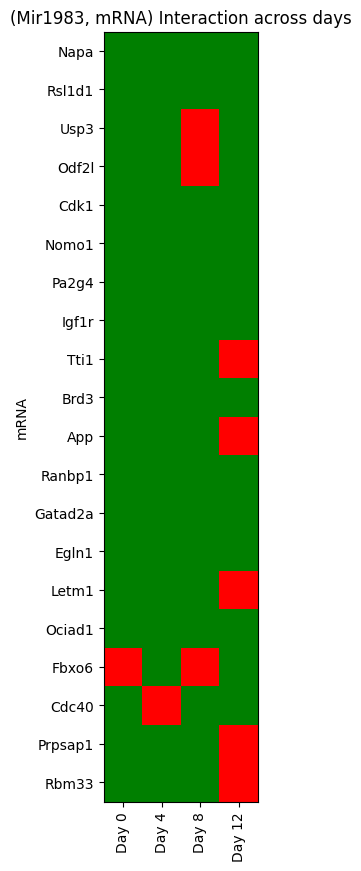

In [71]:
g = 20

cmap = LinearSegmentedColormap.from_list('GR', [(0, "g"), (1, "r")])

fig, axs = plt.subplots(figsize=(10, 10))

img = axs.imshow(status_array[:g], cmap=cmap)
#axs.set_xlabel("Days")
axs.set_xticks(range(4), labels=[f"Day {day}" for day in [0, 4, 8, 12]], rotation="vertical")
#axs.set_xticklabels([f"Day {day}" for day in [0, 4, 8, 12]])
axs.set_ylabel("mRNA")
axs.set_yticks(range(len(mRNA[:g])), labels=mRNA[:g])
#axs.set_yticklabels(mRNA[:g])

#cbar = plt.colorbar(img, ax=axs)
#cbar.set_label("Status")

axs.set_title(f"({miRNA}, mRNA) Interaction across days")


In [72]:
correlation_array = MF_interacting_df[[f'Mir1983_day{day}_d33_t30_ct100_correlation' for day in [0, 4, 8, 12]]].to_numpy()

Text(0.5, 1.0, '(Mir1983, mRNA) Interaction across days')

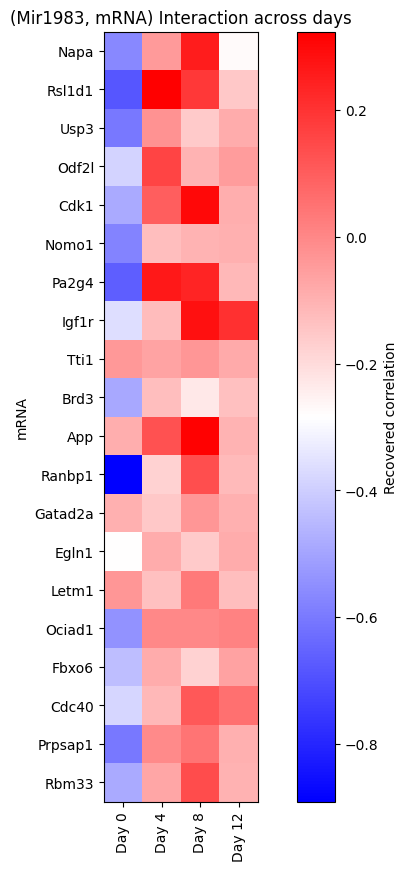

In [ ]:
g = 20

cmap = LinearSegmentedColormap.from_list('BWR', [(0, "b"), (0.5, "w"), (1, "r")])

fig, axs = plt.subplots(figsize=(10, 10))

img = axs.imshow(correlation_array[:g], cmap=cmap)
#axs.set_xlabel("Days")
axs.set_xticks(range(4), labels=[f"Day {day}" for day in [0, 4, 8, 12]], rotation="vertical")
#axs.set_xticklabels([f"Day {day}" for day in [0, 4, 8, 12]])
axs.set_ylabel("mRNA")
axs.set_yticks(range(len(mRNA[:g])), labels=mRNA[:g])
#axs.set_yticklabels(mRNA[:g])

cbar = plt.colorbar(img, ax=axs)
cbar.set_label("Recovered correlation")

axs.set_title(f"({miRNA}, mRNA) Interaction across days")

Text(0.5, 1.0, 'Recovered Correlation across days')

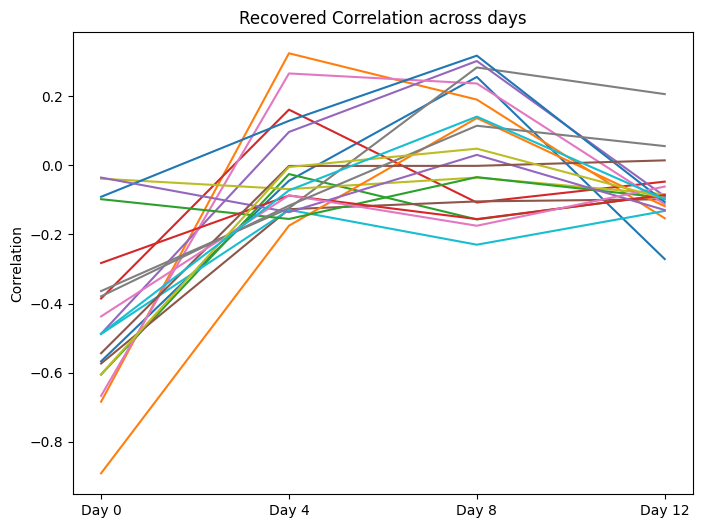

In [83]:
g = 20

fig, axs = plt.subplots(figsize=(8, 6))

for i in range(g):
    axs.plot(correlation_array[i, :])

axs.set_xticks(range(4), labels=[f"Day {day}" for day in [0, 4, 8, 12]])
axs.set_ylabel("Correlation")
axs.set_title("Recovered Correlation across days")